In [1]:
import torch
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [2]:
import torch
import torch
import torch.nn as nn
import torch.nn.functional as F

# -----------------------------
# Shared CNN block for RGB channels
# -----------------------------
class SPRNNBlock(nn.Module):
    def __init__(self, in_channels=2, mid_channels=16, kernel_size=3):
        super(SPRNNBlock, self).__init__()
        padding = kernel_size // 2

        # High-resolution conv layers
        self.conv1 = nn.Conv2d(in_channels, mid_channels, kernel_size, padding=padding)
        self.bn1 = nn.BatchNorm2d(mid_channels)
        self.conv2 = nn.Conv2d(mid_channels, mid_channels, kernel_size, padding=padding)
        self.bn2 = nn.BatchNorm2d(mid_channels)
        self.conv3 = nn.Conv2d(mid_channels, mid_channels, kernel_size, padding=padding)
        self.bn3 = nn.BatchNorm2d(mid_channels)

        # MaxPool - stride varies based on color
        self.maxpool_g = nn.MaxPool2d(kernel_size=2, stride=2)
        self.maxpool_rb = nn.MaxPool2d(kernel_size=(2, 4), stride=(2, 4))

        # Low-resolution conv layers
        self.conv4 = nn.Conv2d(mid_channels, mid_channels, kernel_size, padding=padding)
        self.bn4 = nn.BatchNorm2d(mid_channels)
        self.conv5 = nn.Conv2d(mid_channels, 1, kernel_size, padding=padding)
        self.bn5 = nn.BatchNorm2d(1)
        self.relu = nn.ReLU()

    def forward(self, x, color):
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.relu(self.bn2(self.conv2(x)))
        x = self.relu(self.bn3(self.conv3(x)))

        if color == 'G':
            x = self.maxpool_g(x)
        else:
            x = self.maxpool_rb(x)

        x = self.relu(self.bn4(self.conv4(x)))
        x = self.bn5(self.conv5(x))
        return x



# -----------------------------
# Full SPRNN Model
# -----------------------------
class SPRNN(nn.Module):
    def __init__(self):
        super(SPRNN, self).__init__()
        self.shared_block = SPRNNBlock()

    def forward(self, Ir, Ig, Ib, Pr, Pg, Pb):
        # align the dimension to torch.cat
        if Ir.dim() == 3: Ir = Ir.unsqueeze(1)
        if Ig.dim() == 3: Ig = Ig.unsqueeze(1)
        if Ib.dim() == 3: Ib = Ib.unsqueeze(1)
        # Concatenate input image with pixel layout mask for each color
        Dr = self.shared_block(torch.cat([Ir, Pr], dim=1), 'R')
        Dg = self.shared_block(torch.cat([Ig, Pg], dim=1), 'G')
        Db = self.shared_block(torch.cat([Ib, Pb], dim=1), 'B')
        return Dr, Dg, Db
    
    
    
class SPRNNBlockNoBN(nn.Module):
    def __init__(self, in_channels=2, mid_channels=16, kernel_size=3):
        super().__init__()
        padding = kernel_size // 2

        # Conv만 남깁니다
        self.conv1 = nn.Conv2d(in_channels,  mid_channels, kernel_size, padding=padding)
        self.conv2 = nn.Conv2d(mid_channels,   mid_channels, kernel_size, padding=padding)
        self.conv3 = nn.Conv2d(mid_channels,   mid_channels, kernel_size, padding=padding)
        self.conv4 = nn.Conv2d(mid_channels,   mid_channels, kernel_size, padding=padding)
        self.conv5 = nn.Conv2d(mid_channels,             1, kernel_size, padding=padding)

        self.maxpool_g  = nn.MaxPool2d(2,      2)
        self.maxpool_rb = nn.MaxPool2d((2, 4), (2, 4))
        self.relu       = nn.ReLU()

    def forward(self, x, color):
        # BN 없는 경우 그냥 Conv→ReLU 순서로 바꿔줍니다
        x = self.relu(self.conv1(x))
        x = self.relu(self.conv2(x))
        x = self.relu(self.conv3(x))

        x = self.maxpool_g(x)  if color=='G' else self.maxpool_rb(x)

        x = self.relu(self.conv4(x))
        x = self.conv5(x)      # 마지막엔 활성화 없이 그대로 내보냅니다
        return x


class SPRNNNoBN(nn.Module):
    def __init__(self):
        super(SPRNNNoBN, self).__init__()
        self.shared_block = SPRNNBlockNoBN()

    def forward(self, Ir, Ig, Ib, Pr, Pg, Pb):
        # align the dimension to torch.cat
        if Ir.dim() == 3: Ir = Ir.unsqueeze(1)
        if Ig.dim() == 3: Ig = Ig.unsqueeze(1)
        if Ib.dim() == 3: Ib = Ib.unsqueeze(1)
        # Concatenate input image with pixel layout mask for each color
        Dr = self.shared_block(torch.cat([Ir, Pr], dim=1), 'R')
        Dg = self.shared_block(torch.cat([Ig, Pg], dim=1), 'G')
        Db = self.shared_block(torch.cat([Ib, Pb], dim=1), 'B')
        return Dr, Dg, Db   

In [3]:
from torch.utils.data import Dataset
import torch
import torch.nn.functional as F

class SubpixelDataset(Dataset):
    def __init__(self, image_list):
        self.image_list = image_list  # list of (Ir, Ig, Ib, Pr, Pg, Pb)

    def __len__(self):
        return len(self.image_list)

    def __getitem__(self, idx):
        Ir, Ig, Ib, Pr, Pg, Pb = self.image_list[idx]
        return Ir, Ig, Ib, Pr, Pg, Pb

def remap_and_convolve(D, P, kernel):
    """
    Maps subpixel pattern D to a zero-padded full-resolution pattern using P, then applies bilinear convolution.
    D: [B, 1, h, w]
    P: [B, 1, H, W]
    """
    B, _, H, W = P.shape
    Z = torch.zeros_like(P)
    mask = (P == 1)
    
    # Map low-res D to high-res Z
    for b in range(B):
        d_idx = 0
        for i in range(H):
            for j in range(W):
                if P[b, 0, i, j] == 1:
                    ni = i // 2
                    nj = j // 4 if D.shape[-1] * 4 == W else j // 2
                    Z[b, 0, i, j] = D[b, 0, ni, nj]
    # Convolve with kernel
    kernel = kernel.to(Z.device).unsqueeze(0).unsqueeze(0)
    Z_blur = F.conv2d(Z, kernel, padding=kernel.shape[-1]//2)
    return Z_blur

def get_hvs_kernels():
    Crb = torch.tensor([
        [0, 0, 0, 0.06, 0, 0, 0],
        [0, 0, 0.19, 0.25, 0.19, 0, 0],
        [0, 0.19, 0.50, 0.56, 0.50, 0.19, 0],
        [0.06, 0.25, 0.56, 1.0, 0.56, 0.25, 0.06],
        [0, 0.19, 0.50, 0.56, 0.50, 0.19, 0],
        [0, 0, 0.19, 0.25, 0.19, 0, 0],
        [0, 0, 0, 0.06, 0, 0, 0]
    ], dtype=torch.float32)

    Cg = torch.tensor([
        [0.25, 0.50, 0.25],
        [0.50, 1.00, 0.50],
        [0.25, 0.50, 0.25]
    ], dtype=torch.float32)

    return Crb, Cg

def generate_pixel_masks(H, W):
    Pr = torch.zeros(1, H, W)
    Pg = torch.zeros(1, H, W)
    Pb = torch.zeros(1, H, W)

    for i in range(H):
        for j in range(W):
            if (i % 4 == 1 and j % 4 == 1) or (i % 4 == 3 and j % 4 == 3):
                Pr[0, i, j] = 1
            if i % 2 == 0 and j % 2 == 0:
                Pg[0, i, j] = 1
            if (i % 4 == 1 and j % 4 == 3) or (i % 4 == 3 and j % 4 == 1):
                Pb[0, i, j] = 1

    return Pr, Pg, Pb

import os
import random
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF
import torchvision
import torchvision.transforms as transforms

class DIV2KDataset(Dataset):
    def __init__(self, root_dir, transform=None, img_size=256):
        """
        Args:
            root_dir (str): Path to DIV2K image folder
            transform (callable, optional): A torchvision-style transform pipeline
        """
        self.root_dir = root_dir
        self.transform = transform
        self.image_files = sorted([
            f for f in os.listdir(root_dir) if f.endswith(('.png', '.jpg'))
        ])
        self.img_size = img_size
    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_path = os.path.join(self.root_dir, self.image_files[idx])
        img = Image.open(img_path).convert("RGB")

        if self.transform:
            img = self.transform(img)
        else:
            img = transforms.ToTensor()(img)
        #print(img.shape)
        Pr, Pg, Pb = generate_pixel_masks(self.img_size, self.img_size)
        return img[0:1], img[1:2], img[2:3], Pr, Pg, Pb
    
    
    



In [4]:
# -------------------------------
## eval dataset
# -------------------------------

image_size = 100
eval_transform = transforms.Compose([
        transforms.RandomCrop((image_size, image_size)),
        transforms.ToTensor()
        ])

div2k_test_dir = 'DIV2K_test_HR'
b_size = 1

eval_dataset = DIV2KDataset(root_dir=div2k_test_dir, img_size=image_size, transform=eval_transform)  # Just normalization
eval_loader = DataLoader(SubpixelDataset(eval_dataset), batch_size=b_size, shuffle=False)

model = SPRNN()
checkpoint = torch.load('Model_May27_0439.pt', map_location='cuda')
model.load_state_dict(checkpoint)  
model.eval()
model.to('cuda')


SPRNN(
  (shared_block): SPRNNBlock(
    (conv1): Conv2d(2, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (conv2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (bn2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (conv3): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (bn3): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (maxpool_g): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (maxpool_rb): MaxPool2d(kernel_size=(2, 4), stride=(2, 4), padding=0, dilation=1, ceil_mode=False)
    (conv4): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (bn4): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (conv5): Conv2d(16, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (bn5): 

In [5]:
import copy
datatype = torch.int8
cal_dtype = torch.int64
chosen_bitwidth = 8

In [6]:
def get_quantized_range(bitwidth):
    quantized_max = (1 << (bitwidth - 1)) - 1
    quantized_min = -(1 << (bitwidth - 1))
    return quantized_min, quantized_max

In [7]:
def linear_quantize(fp_tensor, bitwidth, scale, zero_point, dtype=datatype) -> torch.Tensor:
    """
    linear quantization for single fp_tensor
      from
        fp_tensor = (quantized_tensor - zero_point) * scale
      we have,
        quantized_tensor = int(round(fp_tensor / scale)) + zero_point
    :param tensor: [torch.(cuda.)FloatTensor] floating tensor to be quantized
    :param bitwidth: [int] quantization bit width
    :param scale: [torch.(cuda.)FloatTensor] scaling factor
    :param zero_point: [torch.(cuda.)IntTensor] the desired centroid of tensor values
    :return:
        [torch.(cuda.)FloatTensor] quantized tensor whose values are integers
    """
    assert(fp_tensor.dtype == torch.float)
    print(scale.dim(), fp_tensor.dim())
    assert(isinstance(scale, float) or
           (scale.dtype == torch.float and scale.dim() == fp_tensor.dim()))
    assert(isinstance(zero_point, int) or
           (zero_point.dtype == dtype and zero_point.dim() == fp_tensor.dim()))

    # Step 1: scale the fp_tensor
    scaled_tensor = fp_tensor/scale
    #print('scaled tensor: ', scaled_tensor)
    # Step 2: round the floating value to integer value
    rounded_tensor = torch.round(scaled_tensor)

    rounded_tensor = rounded_tensor.to(dtype)
    #print('rounded_Tensor: ', rounded_tensor)
    # Step 3: shift the rounded_tensor to make zero_point 0
    shifted_tensor = rounded_tensor + zero_point
    #print('shifted_tensor: ', shifted_tensor)
    # Step 4: clamp the shifted_tensor to lie in bitwidth-bit range
    quantized_min, quantized_max = get_quantized_range(bitwidth)
    quantized_tensor = shifted_tensor.clamp_(quantized_min, quantized_max)
    #print('quantized_tensor: ', quantized_tensor)
    return quantized_tensor

In [8]:
def get_quantization_scale_and_zero_point(fp_tensor, bitwidth):
    """
    get quantization scale for single tensor
    :param fp_tensor: [torch.(cuda.)Tensor] floating tensor to be quantized
    :param bitwidth: [int] quantization bit width
    :return:
        [float] scale
        [int] zero_point
    """
    #print(fp_tensor)
    quantized_min, quantized_max = get_quantized_range(bitwidth)
    fp_max = fp_tensor.max().item()
    fp_min = fp_tensor.min().item()

    # hint: one line of code for calculating scale
    scale = (fp_max - fp_min)/(quantized_max - quantized_min)
    if scale == 0:
        scale=1e-9
    
    # hint: one line of code for calculating zero_point
    zero_point = round(quantized_min - fp_min/scale)
    # print("quantized min :", quantized_min)
    # print("quantized max :", quantized_max)
    # print("fp min :", fp_min)
    # print("fp max :", fp_max)
    # print("scale :", scale)
    # print("zero point :", zero_point)

    # clip the zero_point to fall in [quantized_min, quantized_max]
    if zero_point < quantized_min:
        zero_point = quantized_min
    elif zero_point > quantized_max:
        zero_point = quantized_max
    else: # convert from float to int using round()
        zero_point = round(zero_point)
    return scale, int(zero_point)

In [9]:
def linear_quantize_feature(fp_tensor, bitwidth): #diff
    """
    linear quantization for feature tensor
    :param fp_tensor: [torch.(cuda.)Tensor] floating feature to be quantized
    :param bitwidth: [int] quantization bit width
    :return:
        [torch.(cuda.)Tensor] quantized tensor
        [float] scale tensor
        [int] zero point
    """
    scale, zero_point = get_quantization_scale_and_zero_point(fp_tensor, bitwidth)
    quantized_tensor = linear_quantize(fp_tensor, bitwidth, scale, zero_point)
    return quantized_tensor, scale, zero_point

In [10]:
def _find_optimal_clip_threshold(w: torch.Tensor,
                                 bitwidth: int,
                                 num_steps: int = 100) -> float:
    """
    MSE 기반 최적 clipping threshold T* 탐색
    """
    # 1D view & CPU
    w = w.abs().view(-1).cpu()
    max_val = max(w.max().item(), 1e-8)
    thresholds = torch.linspace(max_val / num_steps, max_val, steps=num_steps)
    _, qmax = get_quantized_range(bitwidth)

    best_mse = float('inf')
    best_T = max_val

    for T in thresholds:
        w_clip = w.clamp(-T, T)
        scale = T / qmax
        w_q = (w_clip / scale).round().clamp(-qmax, qmax)
        w_deq = w_q * scale
        mse = torch.mean((w - w_deq) ** 2).item()
        if mse < best_mse:
            best_mse = mse
            best_T = T.item()

    return best_T

def get_quantization_scale_for_weight(weight: torch.Tensor,
                                      bitwidth: int,
                                      mode: str = 'mse',
                                      num_steps: int = 100) -> float:
    """
    weight tensor 하나에 대한 quantization scale 계산
    mode: 'minmax' or 'mse'
    """
    _, qmax = get_quantized_range(bitwidth)

    if mode == 'minmax':
        fp_max = max(weight.abs().max().item(), 5e-7)
        return fp_max / qmax

    elif mode == 'mse':
        w = weight.detach().cpu().view(-1)
        T_opt = _find_optimal_clip_threshold(w, bitwidth, num_steps)
        print('optimal T:', T_opt)
        return T_opt / qmax

    else:
        raise ValueError(f"Unsupported mode: {mode}")

In [11]:
def linear_quantize_weight_per_channel(tensor, bitwidth): #diff
    """
    linear quantization for weight tensor
        using different scales and zero_points for different output channels
    :param tensor: [torch.(cuda.)Tensor] floating weight to be quantized
    :param bitwidth: [int] quantization bit width
    :return:
        [torch.(cuda.)Tensor] quantized tensor
        [torch.(cuda.)Tensor] scale tensor
        [int] zero point (which is always 0)
    """
    customconv2d = (tensor.dim() != 4)

    # get the number of output channels
    dim_output_channels = 1 if customconv2d else 0
    dim_output_height = 0 if customconv2d else None
    num_output_channels = tensor.shape[dim_output_channels]
    num_output_height = tensor.shape[dim_output_height] if customconv2d else None
    
    # create array of zeros to contain scale (per channel quantization)
    scale = torch.zeros(num_output_height, num_output_channels, device=tensor.device) if customconv2d else torch.zeros(num_output_channels, device=tensor.device) 
    
    if customconv2d:
        # --- customconv2d branch ---
        OH, IC, _, KH, KW = tensor.shape

        # 1) (h, c)별 스케일 저장용
        scale = torch.zeros(OH, IC, device=tensor.device)

        # 2) height x channel 순회하며 scale 계산
        #for h in range(OH):
        for c in range(IC):
            # subtensor: shape (1, KH, KW)
            subt = tensor[:, c, 0, :, :]
            scale[:, c] = get_quantization_scale_for_weight(subt, bitwidth)
            #print('getting weight scale', subt, scale[:,c])

        # 3) (OH,IC) → (OH,IC,1,1,1) 브로드캐스트 준비
        scale = scale.view(OH, IC, 1, 1, 1)
        quantized_tensor = torch.zeros_like(tensor, dtype=datatype, device=tensor.device)
        # 4) quantize 호출
        #for h in range(OH):
        for c in range(IC):
            #print('during weight quant')
            #print("tensor", tensor[:, c:c+1, :, :, :])
            #print("scale", scale[:, c:c+1, :, :, :])
            quantized_tensor[:, c:c+1, :, :, :] = linear_quantize(tensor[:, c:c+1, :, :, :], bitwidth, scale[:, c:c+1, :, :, :], zero_point=0)
            #print("quantized_tensor", quantized_tensor[:, c:c+1, :, :, :])
        return quantized_tensor, scale, 0
        
    else: # nn.conv2d:
         # Compute Scale Factors for Each Output Channel
        for oc in range(num_output_channels):
            _subtensor = tensor.select(dim_output_channels, oc) #torch.select(input, dim, index) (=input.select(dim, index))
            _scale = get_quantization_scale_for_weight(_subtensor, bitwidth)
            scale[oc] = _scale
        
        # Reshape Scale Tensor for Broadcasting
        scale_shape = [1] * tensor.dim()
        scale_shape[dim_output_channels] = -1 # tensor (b, c, h, w) -> scale (c, 1, 1, 1)
        scale = scale.view(scale_shape)
        # Perform Quantization
        quantized_tensor = linear_quantize(tensor, bitwidth, scale, zero_point=0)
    
    return quantized_tensor, scale, 0 #zero point = 0

In [12]:

def linear_quantize_bias_per_output_channel(bias, weight_scale, input_scale, bitwidth, oh=None, spec_groups=None): #diff
    """
    linear quantization for single bias tensor
        quantized_bias = fp_bias / bias_scale
    :param bias: [torch.FloatTensor] bias weight to be quantized
    :param weight_scale: [float or torch.FloatTensor] weight scale tensor
    :param input_scale: [float] input scale
    :return:
        [torch.IntTensor] quantized bias tensor
    """
    #assert(bias.dim() == 1)
    customconv2d= False #default
    if bias.dim() != 1:  #(oh, ic) 
        customconv2d = True
    assert(bias.dtype == torch.float)
    assert(isinstance(input_scale, float))
    if isinstance(weight_scale, torch.Tensor): # if customconv2d
        weight_scale = weight_scale.squeeze() # (oh, ic, 1, 1, 1) -> (oh, ic)
        assert(weight_scale.dtype == torch.float)
        assert(bias.numel() == weight_scale.numel())

    bias_scale = weight_scale * input_scale # (oh, ic) = (oh, ic) * float    
    
    

    #print('bias: ', bias.shape, bias)
    #print("bias shape: ", bias.shape, "bias scale shape: ", bias_scale.shape)
    print('oh: ', oh, 'spec_groups: ', spec_groups)
    
    if customconv2d:
        assert(oh%spec_groups==0 ), "dimension error : oh%spec_groups should be 0"
    if bias_scale.dim() == 0:
        bias_scale = bias_scale.unsqueeze(0)
    # print("bias shape: ", bias.shape, bias, "bias scale shape: ", bias_scale.shape)
    quantized_bias = linear_quantize(bias, 32, bias_scale,
                                     zero_point=0, dtype=torch.int32)
    
    print("weight scale :", weight_scale, "input scale: ", input_scale)
    print('bias scale: ', bias_scale)
    #print('quantized_bias')
    #print(quantized_bias.shape, quantized_bias)
    return quantized_bias, bias_scale, 0

In [13]:
def shift_quantized_linear_bias(quantized_bias, quantized_weight, input_zero_point):
    """
    shift quantized bias to incorporate input_zero_point for nn.Linear
        shifted_quantized_bias = quantized_bias - Linear(input_zero_point, quantized_weight)
    :param quantized_bias: [torch.IntTensor] quantized bias (torch.int32)
    :param quantized_weight: [torch.CharTensor] quantized weight (datatype)
    :param input_zero_point: [int] input zero point
    :return:
        [torch.IntTensor] shifted quantized bias tensor
    """
    assert(quantized_bias.dtype == torch.int32)
    assert(isinstance(input_zero_point, int))
    return quantized_bias - quantized_weight.sum(1).to(torch.int32) * input_zero_point

In [14]:
def shift_quantized_conv2d_bias(quantized_bias, quantized_weight, input_zero_point):
    """
    Shift quantized bias to incorporate input_zero_point for nn.Conv2d (incl. custom/depthwise).
      shifted_bias = quantized_bias - input_zero_point * sum(quantized_weight)
    :param quantized_bias: torch.IntTensor, dtype=torch.int32, shape (OC,) or (OH,IC)
    :param quantized_weight: torch.IntTensor, dtype=datatype, shape
           - normal conv: (OC, IC, KH, KW)
           - custom depthwise: (OH, IC, 1, KH, KW)
    :param input_zero_point: int
    :return: torch.IntTensor, dtype=torch.int32, same shape as quantized_bias
    """
    assert quantized_bias.dtype == torch.int32
    assert isinstance(input_zero_point, int)

    # 1) weight 차원에 상관없이 입력 채널+커널 축을 합산
    if quantized_weight.dim() == 5:
        # custom conv: weight.shape = (OH, IC, 1, KH, KW)
        sum_axes = (2, 3, 4)
    elif quantized_weight.dim() == 4:
        # 일반 conv: weight.shape = (OC, IC, KH, KW)
        sum_axes = (1, 2, 3) 
    else:
        raise ValueError(f"Unsupported weight.dim(): {quantized_weight.dim()}")
    
    # sum → int32 유지
    weight_sum = quantized_weight.sum(dim=sum_axes).to(torch.int32)
    # shifted_bias 계산 (int32 유지)
    shifted_bias = quantized_bias - weight_sum * input_zero_point
    #print('quantized_weight: ', quantized_weight.shape, quantized_weight)
    #print('quantized_bias', quantized_bias.shape, quantized_bias)
    #print('input zero point', input_zero_point)
    #print('shifted bias', shifted_bias.shape, shifted_bias)
    return shifted_bias


In [15]:
def quantized_conv2d(input, weight, bias, feature_bitwidth, weight_bitwidth,
                     input_zero_point, output_zero_point,
                     input_scale, weight_scale, output_scale,
                     stride, padding, dilation, groups):
    """
    quantized 2d convolution
    :param input: [torch.CharTensor] quantized input (datatype)
    :param weight: [torch.CharTensor] quantized weight (datatype)
    :param bias: [torch.IntTensor] shifted quantized bias or None (datatype)
    :param feature_bitwidth: [int] quantization bit width of input and output
    :param weight_bitwidth: [int] quantization bit width of weight
    :param input_zero_point: [int] input zero point
    :param output_zero_point: [int] output zero point
    :param input_scale: [float] input feature scale
    :param weight_scale: [torch.FloatTensor] weight per-channel scale
    :param output_scale: [float] output feature scale
    :return:
        [torch.(cuda.)CharTensor] quantized output feature
    """
    assert(len(padding) == 4)
    
    assert(bias is None or bias.dtype == torch.int32)
    assert(isinstance(input_zero_point, int))
    assert(isinstance(output_zero_point, int))
    assert(isinstance(input_scale, float))
    assert(isinstance(output_scale, float))
    assert(weight_scale.dtype == torch.float)
   # Step 1: calculate integer-based 2d convolution (8-bit multiplication with 32-bit accumulation)
    input = torch.nn.functional.pad(input, padding, 'constant', input_zero_point)
    if 'cpu' in input.device.type:
        # use 32-b MAC for simplicity
        output = torch.nn.functional.conv2d(input.to(cal_dtype), weight.to(cal_dtype), None, stride, 0, dilation, groups)
    else:
        # current version pytorch does not yet support integer-based conv2d() on GPUs
        output = torch.nn.functional.conv2d(input.float(), weight.float(), None, stride, 0, dilation, groups)
        output = output.round().to(cal_dtype)
    if bias is not None:
        output = output + bias.view(1, -1, 1, 1)
    #print('inside quantized conv2d')
    #print(output)

    # Step 2: scale the output
    #         hint: 1. scales are floating numbers, we need to convert output to float as well
    #               2. the shape of weight scale is [oc, 1, 1, 1] while the shape of output is [batch_size, oc, height, width]
    output = output.to(torch.float)*input_scale*(weight_scale.unsqueeze(0).squeeze(-1))/output_scale
    #print(output)
    # Step 3: shift output by output_zero_point
    #         hint: one line of code
    output = output + output_zero_point
    #print(output)
    # Make sure all value lies in the bitwidth-bit range
    output = output.round().clamp(*get_quantized_range(chosen_bitwidth)).to(datatype)
    
    
    #print("output of quantized conv2d: ", output.shape, output[0])
    #torch.save(output, f'output_conv2d{datetime.now().strftime("%B%d_%H%M%S")}.pt')
    return output

In [16]:
def quantized_linear(input, weight, bias, feature_bitwidth, weight_bitwidth,
                     input_zero_point, output_zero_point,
                     input_scale, weight_scale, output_scale):
    """
    quantized fully-connected layer
    :param input: [torch.CharTensor] quantized input (torch.int32)
    :param weight: [torch.CharTensor] quantized weight (torch.int32)
    :param bias: [torch.IntTensor] shifted quantized bias or None (torch.int32)
    :param feature_bitwidth: [int] quantization bit width of input and output
    :param weight_bitwidth: [int] quantization bit width of weight
    :param input_zero_point: [int] input zero point
    :param output_zero_point: [int] output zero point
    :param input_scale: [float] input feature scale
    :param weight_scale: [torch.FloatTensor] weight per-channel scale
    :param output_scale: [float] output feature scale
    :return:
        [torch.CharIntTensor] quantized output feature (torch.int32)
    """
    assert(input.dtype == datatype)
    assert(weight.dtype == input.dtype)
    assert(bias is None or bias.dtype == torch.int32)
    assert(isinstance(input_zero_point, int))
    assert(isinstance(output_zero_point, int))
    assert(isinstance(input_scale, float))
    assert(isinstance(output_scale, float))
    assert(weight_scale.dtype == torch.float)

    # Step 1: integer-based fully-connected (8-bit multiplication with 32-bit accumulation)
    if 'cpu' in input.device.type:
        # use 32-b MAC for simplicity
        output = torch.nn.functional.linear(input.to(torch.int32), weight.to(torch.int32), bias)
    else:
        # current version pytorch does not yet support integer-based linear() on GPUs
        output = torch.nn.functional.linear(input.float(), weight.float(), bias.float())

    # Step 2: scale the output
    output = output.to(torch.float)*input_scale*weight_scale.squeeze()/output_scale

    # Step 3: shift output by output_zero_point
    output = output + output_zero_point

    # Make sure all value lies in the bitwidth-bit range
    output = output.round().clamp(*get_quantized_range(feature_bitwidth)).to(datatype)
    return output

In [17]:
import torch.nn as nn
import torch
import copy

def fuse_conv_bn(conv, bn):
    # Ensure the conv is a 2D convolution
    assert isinstance(conv, nn.Conv2d) and isinstance(bn, nn.BatchNorm2d), "conv must be Conv2d and bn must be BatchNorm2d"
    device = conv.weight.device
    bn.weight.data = bn.weight.data.to(device)
    bn.bias.data = bn.bias.data.to(device)  
    
    # Compute scaling factor for weights
    factor = bn.weight.data / torch.sqrt(bn.running_var.data + bn.eps)
    
    if conv.groups != 1:  # Depthwise convolution case
        factor = factor.reshape(conv.out_channels, 1, 1, 1)  # Match depthwise conv weight shape
    else:  # Standard convolution case
        factor = factor.reshape(-1, 1, 1, 1)  # Match normal conv weight shape

    conv.weight.data *= factor  # Scale weights

    # Compute new bias
    if conv.bias is not None:
        conv.bias.data = (conv.bias.data - bn.running_mean.data) * factor.flatten() + bn.bias.data
    else:
        conv.bias = nn.Parameter(-bn.running_mean.data * factor.flatten() + bn.bias.data)
    
    return conv



def fuse_bn_conv(bn: nn.BatchNorm2d, conv: nn.Conv2d):

    wbn=bn.weight.data
    bbn=bn.bias.data
    mean=bn.running_mean
    var=bn.running_var
    eps=bn.eps

    std = torch.sqrt(var + eps)
    scale_factor = wbn / std
    bn_weight=scale_factor
    bn_bias=-mean*scale_factor +bbn

    conv_weight=conv.weight.data.squeeze()
    conv_bias=conv.bias.data
    
    total_weight=(conv_weight*bn_weight.unsqueeze(1).T).unsqueeze(2).unsqueeze(2)
    total_bias=conv_weight@bn_bias+conv_bias

    # Update Conv weights: Scale along input channel axis
    conv.weight.data = nn.Parameter(total_weight)

    # Update Conv bias
    conv.bias = nn.Parameter(total_bias)

    return conv
    


def fuse_conv_ssn(conv: nn.Conv2d, ssn: nn.BatchNorm2d):
    """Fuses a Conv2D layer with a SubSpectralNorm layer for quantization."""
    #if not isinstance(conv, nn.Conv2d) or not isinstance(ssn, SubSpectralNorm):
    #    raise ValueError("Inputs must be a Conv2d layer and a SubSpectralNorm layer")

    # Create instance of CustomConv2d
    fused_layer = CustomConv2d(conv, ssn)    
    
    return fused_layer

def get_next_layer(input_model, current_layer_name, found=False):
    """
    Recursively searches for the next layer in the input_model hierarchy.
    Handles nested nn.Sequential and other module containers.
    """
    children = list(input_model.named_children())  # Get ordered list of layers

    for idx, (name, module) in enumerate(children):
        full_name = name if not found else None

        if found:  # Return the first layer after the matched layer
            return name, module

        if name == current_layer_name:
            found = True  # Mark when we find the current layer

        # If the module is an nn.Sequential, search inside it recursively
        if isinstance(module, nn.Sequential):
            for sub_name, sub_module in module.named_children():
                full_sub_name = f"{name}.{sub_name}"
                if found:
                    return full_sub_name, sub_module  # Found next layer inside Sequential
                if full_sub_name == current_layer_name:
                    found = True

    return None, None  # If no next layer is found




# Recursive function to fuse conv+bn, bn+conv, conv+ssn
def fuse_module(input_model, parent_name=""):
    """
    Recursively explores the input_model and replaces 
        Conv2d + BN -> Conv2d
        Conv2d + SSN -> CustomConv2d
        BN + Conv2d -> Conv2d
    """
    if isinstance(input_model, nn.Module):
        children_copy = list(input_model.named_children())  # Copy of children list to avoid modifying while iterating
        for child_name, child in children_copy:
            full_name = f"{parent_name}.{child_name}" if parent_name else child_name
            # Recursively replace in sub-modules
            fuse_module(child, full_name)
            
            if isinstance(child, nn.Conv2d):
                next_layer_name, next_layer = get_next_layer(input_model, child_name)
                # Check if Conv2d is followed by BatchNorm2d in the same module
                if isinstance(next_layer, nn.BatchNorm2d):
                    input_model._modules[child_name]=fuse_conv_bn(child, next_layer)
                    del input_model._modules[next_layer_name]
                    print(f'fused Conv2d + BN at layer: {full_name}')
                
                # Check if Conv2d is followed by SubSpectralNorm in the same module    
                elif isinstance(next_layer, subspectralnorm.SubSpectralNorm):
                    input_model._modules[child_name]=fuse_conv_ssn(child, next_layer)
                    del input_model._modules[next_layer_name]
                    print(f'fused Conv2d + SSN at layer: {full_name}')
                
            elif isinstance(child, nn.BatchNorm2d):
                next_layer_name, next_layer = get_next_layer(input_model, child_name)
                
                # Check if BN2d is collowed by Conv2d in the same module
                if isinstance(next_layer, nn.Conv2d):
                    input_model._modules[child_name]=fuse_bn_conv(child, next_layer)
                    del input_model._modules[next_layer_name]
                    print(f'fused BN + Conv2d  at layer: {full_name}')
            
        return input_model
    return input_model


In [18]:
"""
    Quantized modules including
        - QuantizedConv2d
        - QuantizedLinear
        - QuantizedMaxPool2d
        - QuantizedAvgPool2d
        - QuantizedCustomConv2d
"""
class QuantizedConv2d(nn.Module):
    def __init__(self, weight, bias,
                 input_zero_point, output_zero_point,
                 input_scale, weight_scale, output_scale,
                 stride, padding, dilation, groups,
                 feature_bitwidth, weight_bitwidth):
        super().__init__()
        # current version Pytorch does not support IntTensor as register_buffer
        self.register_buffer('weight', weight)
        self.register_buffer('bias', bias)

        self.input_zero_point = input_zero_point
        self.output_zero_point = output_zero_point

        self.input_scale = input_scale
        self.register_buffer('weight_scale', weight_scale)
        self.output_scale = output_scale

        self.stride = stride
        self.padding = (padding[1], padding[1], padding[0], padding[0])
        self.dilation = dilation
        self.groups = groups

        self.feature_bitwidth = feature_bitwidth
        self.weight_bitwidth = weight_bitwidth


    def forward(self, x):
        #print("input of quantized conv2d: ",x.shape, x)
        return quantized_conv2d(
            x, self.weight, self.bias,
            self.feature_bitwidth, self.weight_bitwidth,
            self.input_zero_point, self.output_zero_point,
            self.input_scale, self.weight_scale, self.output_scale,
            self.stride, self.padding, self.dilation, self.groups
            )



class QuantizedMaxPool2d(nn.Module):
    def __init__(self, kernel_size, scale, zero_point):
        super().__init__()
        self.kernel_size = kernel_size
        self.scale = scale
        self.zero_point = zero_point

    def forward(self, x_q):
        # 1) dequantize
        x_f = (x_q.to(torch.int32) - self.zero_point).float() * self.scale
        # 2) float 공간에서 풀링
        y_f = F.max_pool2d(x_f, self.kernel_size)
        # 3) re-quantize
        y_q = torch.round(y_f / self.scale) + self.zero_point
        # 4) clamp & dtype 변환
        qmin, qmax = -32768, 32767     # bitwidth=16 예시
        y_q = torch.clamp(y_q, qmin, qmax).to(x_q.dtype)
        return y_q




class QuantizedCustomReLU(nn.Module):
    def __init__(self,
                 input_scale: float,
                 input_zero_point: int,
                 output_scale: float = None,
                 output_zero_point: int = None):
        super().__init__()
        self.in_s = input_scale
        self.in_z = input_zero_point
        # 보통 ReLU 후엔 같은 스케일/제로포인트를 재사용
        self.out_s = output_scale      or input_scale
        self.out_z = output_zero_point or input_zero_point

    def forward(self, x_int8: torch.Tensor) -> torch.Tensor:
        # 1) dequant
        x_fp32 = (x_int8.float() - self.in_z) * self.in_s
        
        # 2) relu
        y_fp32 = torch.clamp(x_fp32, min=0.0)
        # 3) requant (manual)
        y_q = torch.round(y_fp32 / self.out_s) + self.out_z
        y_q = torch.clamp(y_q, -(2**chosen_bitwidth), (2**(chosen_bitwidth)-1)).to(datatype)
        #print("output of custom relu: ", y_q.shape, y_q[0])
        #torch.save(y_q, f'output_relu_{datetime.now().strftime("%B%d_%H%M%S")}.pt')
        return y_q


In [19]:
def get_quantized_weight_scale_zeropoint(input_activation, output_activation, weight, bias, feature_bitwidth, weight_bitwidth, layer_type=None, oh=None, spec_group=None):
    """
    get the input/output activation range
    - return input/output scale and zero point
    - return weight scale
    - return quantized weight and bias

    Args:
        input_activation (dictionary): range of input activation
        output_activation (dictionary): range of output activation
        weight (torch.tensor): values of weight 
        bias (torch.tensor): values of bias
        feature_bitwidth (int, optional): bitwidth for input/output feature. Defaults to 8.
        weight_bitwidth (int, optional): bitwidth for weight. Defaults to 8.
        oh (int, optional):for CustomConv2d. Defaults to None.
        spec_group (int, optional): for CustomConv2d. Defaults to None.
        customconv2d (bool, optional): if the module is CustomConv2d or not. Defaults to False.

    Returns:
        _type_: _description_
    """
    # Fetch activation stats
    input_scale, input_zero_point = get_quantization_scale_and_zero_point(
        input_activation, feature_bitwidth)
    output_scale, output_zero_point = get_quantization_scale_and_zero_point(
            output_activation, feature_bitwidth)
    #print("before quant, weight", weight.shape, weight)
    # Quantize weights and bias
    quantized_weight, weight_scale, weight_zero_point = \
        linear_quantize_weight_per_channel(weight, weight_bitwidth)
    quantized_bias, bias_scale, bias_zero_point = \
        linear_quantize_bias_per_output_channel(
            bias, weight_scale, input_scale, oh=oh, bitwidth = 32, spec_groups=spec_group) if bias is not None else (None, None, None)
    
    if layer_type == 'conv' or 'customconv2d':
        shifted_quantized_bias = shift_quantized_conv2d_bias(
        quantized_bias, quantized_weight, input_zero_point) if quantized_bias is not None else None
    
    elif layer_type == 'linear': 
        shifted_quantized_bias = shift_quantized_linear_bias(
        quantized_bias, quantized_weight, input_zero_point) if quantized_bias is not None else None   
    
    return quantized_weight, shifted_quantized_bias, input_scale, input_zero_point, output_scale, output_zero_point, weight_scale


In [20]:
import torch
import torch.nn as nn

# Recursive function to replace Conv2d followed by ReLU6 with QuantizedConv2d
def recursively_quantize_module(model, input_activation, output_activation, parent_name=""):
    """
    Recursively explores the model and replaces Conv2d followed by ReLU6
    with a QuantizedConv2d.
    """
    if isinstance(model, nn.Module):
        for child_name, child in model.named_children():
            # print(f"Processing child: {child_name, child} of parent: {parent_name}")
            # print(type(child))                 # ← 모델 안 PACTActivation 의 실제 클래스
            # print(PACTActivation)              # ← 현재 스크립트가 들고 있는 클래스
            # print(child.__class__ is PACTActivation)  # True 여야 isinstance 가 먹힘
            # print(child.__class__.__module__)  # 서로 다른 모듈·경로면 다른 클래스
            full_name = f"{parent_name}.{child_name}" if parent_name else child_name
            # Recursively replace in sub-modules
            model._modules[child_name] = recursively_quantize_module(child, input_activation, output_activation, full_name)
            
            if isinstance(child, nn.Conv2d):
                # Construct the activation keys correctly based on the layer name structure
                activation_key = f"{full_name}"  # Use child_name to get the correct key
                print(f"Looking up input_activation for layer: {activation_key}")
                
                if activation_key not in input_activation:
                    print(f"Key '{activation_key}' not found in input_activation")
                    continue
                feature_bitwidth = weight_bitwidth = chosen_bitwidth
                weight = child.weight.data
                bias = child.bias.data if child.bias is not None else None
                quantized_weight, shifted_quantized_bias, input_scale, input_zero_point, output_scale, output_zero_point, weight_scale=\
                get_quantized_weight_scale_zeropoint(
                input_activation[activation_key],   # 1
                output_activation[full_name],       # 2
                weight,                             # 3
                bias,                               # 4
                feature_bitwidth,                   # 5
                weight_bitwidth,                    # 6
                'conv2d',                           # 7 → layer_type
                None,                               # 8 → oh
                None                         # 9 → spec_group
            )
                stride = child.stride
                padding = child.padding
                dilation = child.dilation
                groups = child.groups
                
                # Replace Conv2d with QuantizedConv2d
                model._modules[child_name] = QuantizedConv2d(quantized_weight, shifted_quantized_bias, input_zero_point, output_zero_point,
                                                        input_scale, weight_scale, output_scale,
                                                        stride, padding, dilation, groups, 
                                                        feature_bitwidth, weight_bitwidth)
                
                print(f'Replaced Conv2d with QuantizedConv2d at layer: {full_name}')
                #print(f"quantized with weight scale: {weight_scale}, input scale: {input_scale}, output scale: {output_scale}")
                #print(f'quantized with input zero point: {input_zero_point}, output zero point: {output_zero_point}')
                #print(f'quantized_conv2d_weight: {quantized_weight}, shifted_quantized_bias: {shifted_quantized_bias}')
                
           
                
            elif isinstance(child, nn.MaxPool2d):
                activation_key = f"{full_name}"  # Use child_name to get the correct key
                print(f"Looking up input_activation for layer: {activation_key}")
                
                if activation_key not in input_activation:
                    print(f"Key '{activation_key}' not found in input_activation")
                    continue
                input_scale, input_zero_point = get_quantization_scale_and_zero_point(input_activation[activation_key], bitwidth=chosen_bitwidth)
                output_scale, output_zero_point = get_quantization_scale_and_zero_point(
                    output_activation[full_name], bitwidth=chosen_bitwidth)
                model._modules[child_name] = QuantizedMaxPool2d(child.kernel_size, input_scale, input_zero_point)
                print(f'Replaced nn.MaxPool2d with QuantizedMaxPool2d at layer: {full_name}')
                
            
            
            elif isinstance(child, nn.ReLU) or isinstance(child, nn.SiLU) or isinstance(child, nn.ReLU6):
                activation_key = f"{full_name}"  # Use child_name to get the correct key
                print(f"Looking up input_activation for layer: {activation_key}")
                
                if activation_key not in input_activation:
                    print(f"Key '{activation_key}' not found in input_activation")
                    continue
                input_scale, input_zero_point = get_quantization_scale_and_zero_point(input_activation[activation_key], bitwidth=chosen_bitwidth)
                output_scale, output_zero_point = get_quantization_scale_and_zero_point(
                    output_activation[full_name], bitwidth=chosen_bitwidth)
                model._modules[child_name] = QuantizedCustomReLU(input_scale, input_zero_point, output_scale, output_zero_point)
        
                print(f'Replaced nn.ReLU with QuantizedcustomReLU at layer: {full_name}')
        
            elif isinstance(child, (nn.Sequential, nn.ModuleList)):
                recursively_quantize_module(child, input_activation, output_activation, full_name)
            # Handle ModuleList or Sequential sub-modules
                
                    
        return model
    return model

def init_quantized_model(fused_model, input_activation, output_activation):
    # Deepcopy the model before modifying
    quantized_model = copy.deepcopy(fused_model)

    #you have to manually set the bitwidth for each layer
    
    # Update the model
    quantized_model = recursively_quantize_module(quantized_model, input_activation, output_activation)

    return quantized_model




In [21]:
def linear_quantize_with_predefined_range(feature, feature_record, bitwidth, dtype=datatype):
    quantized_min, quantized_max = get_quantized_range(bitwidth)
    fp_max=feature_record.max().item()
    fp_min=feature_record.min().item()
    
    scale = (fp_max-fp_min)/(quantized_max-quantized_min)
    if scale == 0:
        scale=1e-9
        
    zero_point=round(quantized_min-fp_min/scale)
    if zero_point<quantized_min:
        zero_point=quantized_min
    elif zero_point>quantized_max:
        zero_point=quantized_max
    else:
        zero_point=round(zero_point)
    
    scaled_tensor=feature/scale
    rounded_tensor=torch.round(scaled_tensor)
    rounded_tensor=rounded_tensor.to(dtype)
    shifted_tensor=rounded_tensor+zero_point
    quantized_tensor=shifted_tensor.clamp_(quantized_min, quantized_max)
    # print('fp min: ', fp_min)
    # print('fp_max: ', fp_max)
    # print('scale :', scale)
    # print('zero point: ', zero_point)
    return quantized_tensor  

In [22]:

fused_model = copy.deepcopy(model)
fused_model.eval()

# Update the model
fused_model = fuse_module(fused_model)

# 1) 먼저, BN 없는 새 모델을 인스턴스화
new_model = SPRNNNoBN()   # 또는 여러분이 정의한 SPRNNBlockNoBN 기반 클래스
new_model.to('cuda')
new_model.eval()
# 2) fused_model 에서 모든 파라미터 불러오기
fused_state = fused_model.state_dict()

# 3) new_model 의 state_dict 에 매칭되는 키만 골라서 새로운 dict 생성
#    (bn 레이어가 없는 new_model 에 없는 키들은 자동으로 무시됩니다)
matched_state = {
    k: v
    for k, v in fused_state.items()
    if k in new_model.state_dict()
}

# 4) strict=False 옵션을 주고 로드
new_model.load_state_dict(matched_state, strict=False)

# 이제 new_model 의 conv1, conv2, … conv5 의 weight/bias 가
# fused_model 에서 그대로 넘어왔습니다.


fused Conv2d + BN at layer: shared_block.conv1
fused Conv2d + BN at layer: shared_block.conv2
fused Conv2d + BN at layer: shared_block.conv3
fused Conv2d + BN at layer: shared_block.conv4
fused Conv2d + BN at layer: shared_block.conv5


<All keys matched successfully>

In [23]:
import torch
import torch.nn.functional as F
# ensure that the outputs of model and fused_model are equivalent 

## you have to fix the input dimension to match the model ##
Ir = torch.randn(1, 1, 100, 100).to('cuda')
Ig = torch.randn(1, 1, 100, 100).to('cuda')
Ib = torch.randn(1, 1, 100, 100).to('cuda')
Pr = torch.randn(1, 1, 100, 100).to('cuda')
Pg = torch.randn(1, 1, 100, 100).to('cuda')
Pb = torch.randn(1, 1, 100, 100).to('cuda')

Dr1, Dg, Db = model(Ir, Ig, Ib, Pr, Pg, Pb)

Dr2, Dg, Db = new_model(Ir, Ig, Ib, Pr, Pg, Pb)

print(Dr1)
print(Dr2)

# Compute absolute difference
diff = torch.abs(Dr1 - Dr2)

# Define a threshold for significant differences
threshold = 1e-6  # Adjust based on numerical precision needs
diff_mask = diff > threshold  # Mask of significantly different values

# Print summary statistics
max_diff = diff.max().item()
print(f"Max absolute difference: {max_diff}")

if diff_mask.any():
    print("Values that differ:")
    print("Dr1 differences:", Dr1[diff_mask].detach().cpu().numpy())
    print("Dr2 differences:", Dr2[diff_mask].detach().cpu().numpy())
else:
    print("Outputs are identical within the threshold.")

tensor([[[[ 0.5370,  1.2674,  0.8419,  ...,  0.2495,  1.0261,  0.7529],
          [ 0.0137,  0.8415,  0.3742,  ..., -0.1770,  0.1499,  1.4504],
          [ 0.5611, -0.0462, -0.0823,  ...,  0.7954,  0.7484,  0.4208],
          ...,
          [-0.0429,  0.3684,  0.2772,  ...,  0.2433,  0.6154,  0.1549],
          [ 0.6369,  0.2107,  0.5021,  ...,  0.0438,  0.3450,  0.4719],
          [ 0.6536,  0.3478,  0.4435,  ...,  0.6439,  0.7192, -0.1908]]]],
       device='cuda:0', grad_fn=<CudnnBatchNormBackward0>)
tensor([[[[ 0.5370,  1.2674,  0.8419,  ...,  0.2495,  1.0261,  0.7529],
          [ 0.0137,  0.8415,  0.3742,  ..., -0.1770,  0.1499,  1.4504],
          [ 0.5611, -0.0462, -0.0823,  ...,  0.7954,  0.7484,  0.4208],
          ...,
          [-0.0429,  0.3684,  0.2772,  ...,  0.2433,  0.6154,  0.1549],
          [ 0.6369,  0.2107,  0.5021,  ...,  0.0438,  0.3450,  0.4719],
          [ 0.6536,  0.3478,  0.4435,  ...,  0.6439,  0.7192, -0.1908]]]],
       device='cuda:0', grad_fn=<Convolut

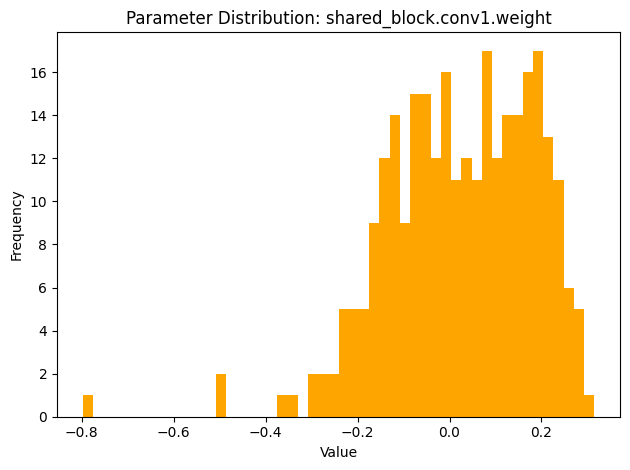

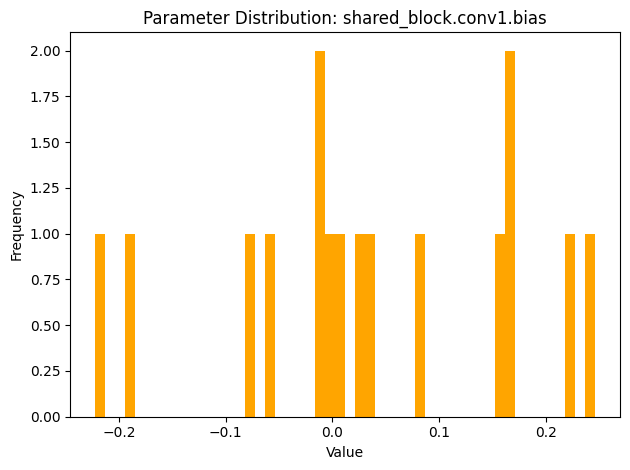

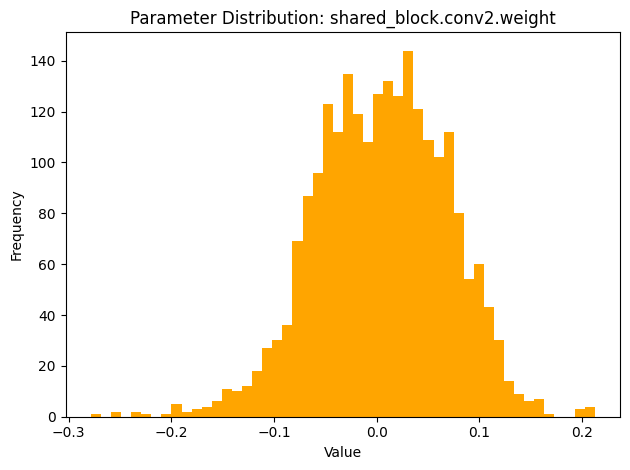

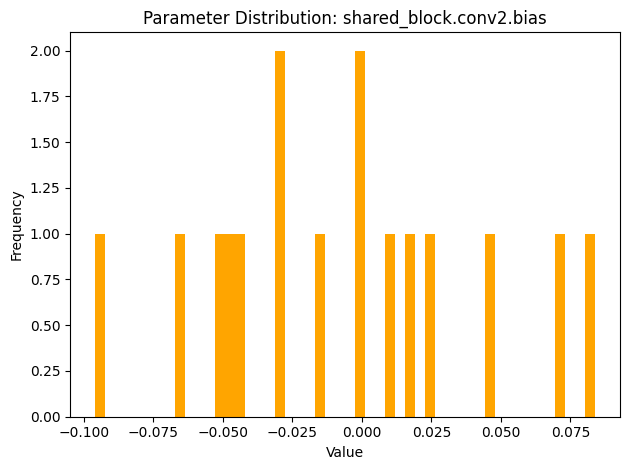

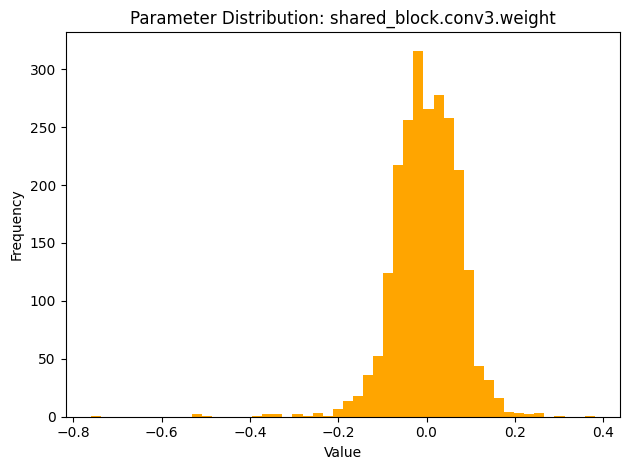

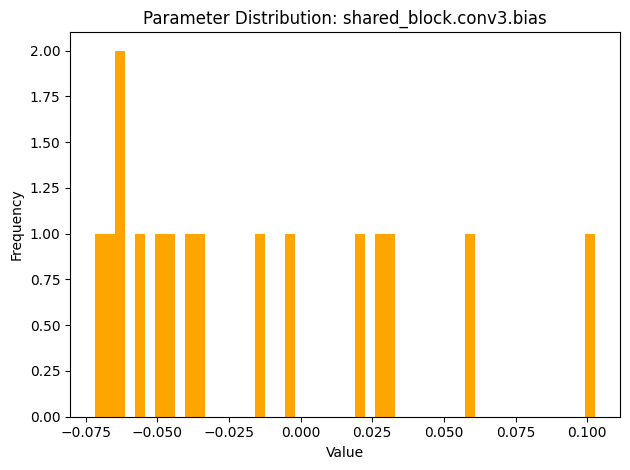

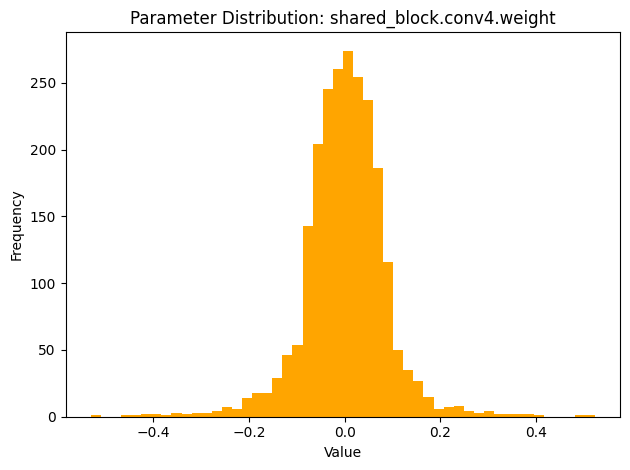

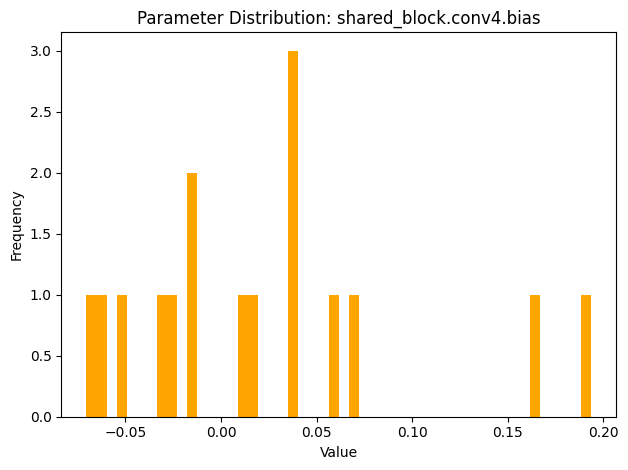

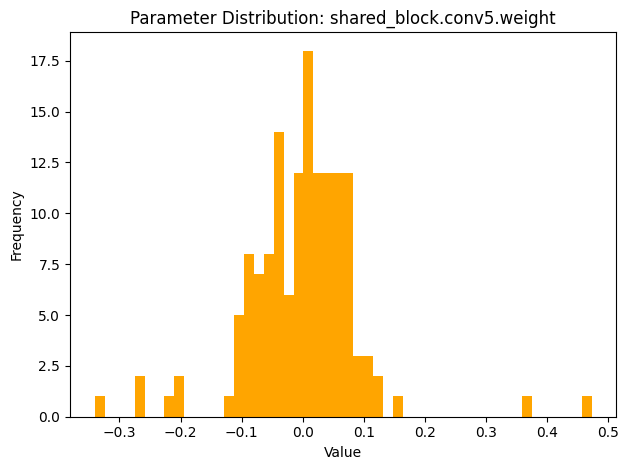

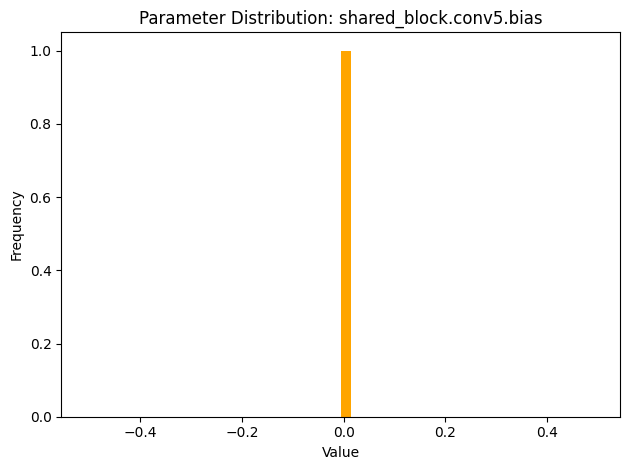

In [24]:
# Example setup:
import torch
import matplotlib.pyplot as plt
import numpy as np

for name, param in new_model.named_parameters():
    if not param.requires_grad:
        continue

    # pull out the data as a flat numpy array
    data = param.detach().cpu().numpy().flatten()

    # mask out any NaNs
    data = data[~np.isnan(data)]

    # if after masking there's nothing left, skip
    if data.size == 0:
        continue

    # now plot
    plt.figure()
    plt.hist(data, bins=50, color='orange')
    plt.title(f'Parameter Distribution: {name}')
    plt.xlabel('Value')
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()


In [25]:
from tqdm import tqdm

def add_range_recoder_hook(model, input_activation, output_activation):
    
    import functools
    def _record_range(self, x, y, module_name):
        x = x[0] #extract the first input tensor (since input is a tuple)
        input_activation[module_name] = x.detach() #without gradient tracking
        output_activation[module_name] = y.detach()

    all_hooks = []
    for name, m in model.named_modules():
        if isinstance(m, (nn.Conv2d, nn.Linear, nn.ReLU, nn.SiLU, nn.ReLU6, nn.AdaptiveAvgPool2d,  nn.AvgPool2d, nn.MaxPool2d)):
            print(f'Adding hook to {name}')
            all_hooks.append(m.register_forward_hook(
                functools.partial(_record_range, module_name=name))) #append _record_range(module_name=name) to the all_hooks list
    return all_hooks

def get_activation_range():
    input_activation = {} #key: module name, value: input activation
    output_activation = {}
    hooks = add_range_recoder_hook(new_model, input_activation, output_activation)
    
    loop = tqdm(eval_loader, leave=False)
    for Ir, Ig, Ib, Pr, Pg, Pb in loop:
        Ir, Ig, Ib = Ir.to(device, non_blocking=True), Ig.to(device, non_blocking=True), Ib.to(device, non_blocking=True)
        Pr, Pg, Pb = Pr.to(device, non_blocking=True), Pg.to(device, non_blocking=True), Pb.to(device, non_blocking=True)
        Dr, Dg, Db = new_model(Ir, Ig, Ib, Pr, Pg, Pb)
        torch.cuda.empty_cache()
        

    ## to update : get the random 512 samples from sample_data

        
    for name, x in input_activation.items():
        print(f'{name} input activation range: [{x.min().item():.2f}, {x.max().item():.2f}]')

    for name, x in output_activation.items():
        print(f'{name} output activation range: [{x.min().item():.2f}, {x.max().item():.2f}]')
    # remove hooks
    for h in hooks:
        h.remove()
        
    return input_activation, output_activation


In [26]:
# add hook to record the min max value of the activation
input_activation = {} #key: module name, value: input activation
output_activation = {}

torch.cuda.empty_cache() # to avoid out of memory problem
input_activation, output_activation=get_activation_range()

Adding hook to shared_block.conv1
Adding hook to shared_block.conv2
Adding hook to shared_block.conv3
Adding hook to shared_block.conv4
Adding hook to shared_block.conv5
Adding hook to shared_block.maxpool_g
Adding hook to shared_block.maxpool_rb
Adding hook to shared_block.relu


shared_block.conv1 input activation range: [0.00, 1.00]
shared_block.relu input activation range: [-3.31, 1.90]
shared_block.conv2 input activation range: [0.00, 1.34]
shared_block.conv3 input activation range: [0.00, 1.34]
shared_block.maxpool_rb input activation range: [0.00, 1.96]
shared_block.conv4 input activation range: [0.00, 1.96]
shared_block.conv5 input activation range: [0.00, 1.90]
shared_block.maxpool_g input activation range: [0.00, 2.02]
shared_block.conv1 output activation range: [-0.80, 1.34]
shared_block.relu output activation range: [0.00, 1.90]
shared_block.conv2 output activation range: [-0.52, 1.34]
shared_block.conv3 output activation range: [-1.32, 1.96]
shared_block.maxpool_rb output activation range: [0.00, 1.96]
shared_block.conv4 output activation range: [-3.31, 1.90]
shared_block.conv5 output activation range: [-0.13, 1.11]
shared_block.maxpool_g output activation range: [0.00, 2.02]


In [27]:
# get the quantized model
quantized_model = init_quantized_model(new_model, input_activation, output_activation)
print(quantized_model)

Looking up input_activation for layer: shared_block.conv1
optimal T: 0.7982022762298584
optimal T: 0.22310379147529602
optimal T: 0.2695885896682739
optimal T: 0.2261100709438324
optimal T: 0.3004312813282013
optimal T: 0.28200989961624146
optimal T: 0.27113041281700134
optimal T: 0.22516368329524994
optimal T: 0.2251756340265274
optimal T: 0.24442699551582336
optimal T: 0.28146007657051086
optimal T: 0.49895358085632324
optimal T: 0.35054782032966614
optimal T: 0.2555846571922302
optimal T: 0.3654087781906128
optimal T: 0.2413005828857422
4 4
oh:  None spec_groups:  None
1 1
weight scale : tensor([0.0063, 0.0018, 0.0021, 0.0018, 0.0024, 0.0022, 0.0021, 0.0018, 0.0018,
        0.0019, 0.0022, 0.0039, 0.0028, 0.0020, 0.0029, 0.0019],
       device='cuda:0') input scale:  0.00392156862745098
bias scale:  tensor([2.4647e-05, 6.8891e-06, 8.3245e-06, 6.9819e-06, 9.2769e-06, 8.7080e-06,
        8.3721e-06, 6.9527e-06, 6.9531e-06, 7.5475e-06, 8.6911e-06, 1.5407e-05,
        1.0824e-05, 7.8921

In [28]:
def quantize_and_dequantize_with_predefined_range(tensor, range_dict, bitwidth):
    """
    Quantizes the input tensor using the scale and zero point derived from the input activation range.
    Args:
        tensor (torch.float32): The input tensor to be quantized & dequantized.
        input_activation (dict): The activation values (dict values) for each layer (dict keys) for quantization.
        bitwidth (int): The bitwidth for quantization. 
        
    Returns:
        tensor (datatype): The quantized tensor, dequantized tensor
        """
        
    # if tensor.shape == torch.Size([16, 1, 5, 5]):  # replace with BCBlocks.0.0.f2.1.block.0.weight shape
    #     print("fp_max inside quantize func:", range_dict['max'])

    quantized_min, quantized_max = get_quantized_range(bitwidth)
    fp_max = range_dict['max']
    fp_min = range_dict['min']
    scale = (fp_max - fp_min)/(quantized_max - quantized_min)
    if scale == 0:
        scale=1e-9
    zero_point = round(quantized_min - fp_min/scale)
    if zero_point < quantized_min:
        zero_point = quantized_min
    elif zero_point > quantized_max:
        zero_point = quantized_max
    else: # convert from float to int using round()
        zero_point = round(zero_point)
        
    print("quantizing with scale {} and zero point {}".format(scale, zero_point))
    
    quantized_tensor = torch.round(tensor/scale)+zero_point
    quantized_tensor = quantized_tensor.clamp_(quantized_min, quantized_max).to(datatype)
    q_int32 = quantized_tensor.to(cal_dtype) # int 32로 바꾸어서 연산
    dequantized_tensor = (scale*(q_int32 - zero_point)).float()
    return quantized_tensor, dequantized_tensor

In [38]:
def dequantize(tensor, scale, zero_point):
    
    dequantized_tensor = (scale*(tensor - zero_point)).float()
    return  dequantized_tensor

In [29]:
import torch
import torch.nn as nn

#check if there is any weight or bias in the model is not IntTensor
def print_weight_bias_types(model: nn.Module):
    """
    For each sub‐module in `model`, if it has a `weight` or `bias` attribute,
    print out its tensor type (e.g. "torch.cuda.FloatTensor" or "torch.FloatTensor").
    """
    for name, module in model.named_modules():
        # check for weight
        if hasattr(module, 'weight') and module.weight is not None:
            print(f"{name}.weight → {module.weight.dtype}")
        # check for bias
        if hasattr(module, 'bias') and module.bias is not None:
            print(f"{name}.bias   → {module.bias.dtype}")


# Now print all weight/bias types
print_weight_bias_types(quantized_model)


shared_block.conv1.weight → torch.int8
shared_block.conv1.bias   → torch.int32
shared_block.conv2.weight → torch.int8
shared_block.conv2.bias   → torch.int32
shared_block.conv3.weight → torch.int8
shared_block.conv3.bias   → torch.int32
shared_block.conv4.weight → torch.int8
shared_block.conv4.bias   → torch.int32
shared_block.conv5.weight → torch.int8
shared_block.conv5.bias   → torch.int32


In [30]:
input_activation

{'shared_block.conv1': tensor([[[[0.0196, 0.0196, 0.0157,  ..., 0.0196, 0.0157, 0.0235],
           [0.0235, 0.0118, 0.0196,  ..., 0.0196, 0.0196, 0.0275],
           [0.0235, 0.0118, 0.0235,  ..., 0.0157, 0.0235, 0.0275],
           ...,
           [0.0118, 0.0196, 0.0196,  ..., 0.0235, 0.0196, 0.0196],
           [0.0118, 0.0235, 0.0235,  ..., 0.0157, 0.0353, 0.0314],
           [0.0196, 0.0157, 0.0157,  ..., 0.0392, 0.0667, 0.0235]],
 
          [[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 1.0000],
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           ...,
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 1.0000],
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           [0.0000, 1.0000, 0.0000,  ..., 1.0000, 0.0000, 0.0000]]]],
        device='cuda:0'),
 'shared_block.relu': tensor([[[[-0.0156, -0.0077,  0.0136,  ...,  0.0179,  0.0279,  0.0293],
           [-0.0

In [31]:
from skimage.metrics import peak_signal_noise_ratio, structural_similarity

# --- Subpixel Resize ---
def resize_subpixels(Dr, Dg, Db):
    # Dr, Db를 Dg 크기에 맞춰서 업샘플링
    target_size = (Dg.shape[2], Dg.shape[3])  # (height, width)
    Dr_resized = F.interpolate(Dr, size=target_size, mode='bilinear', align_corners=False)
    Db_resized = F.interpolate(Db, size=target_size, mode='bilinear', align_corners=False)
    return Dr_resized, Dg, Db_resized

# --- Merge to RGB ---
def merge_rgb(R, G, B):
    return torch.cat([R, G, B], dim=1)  # (B, 3, H, W)

# --- Calculate PSNR and SSIM directly on tensors ---
def calculate_metrics(gt_img, pred_img):
    # Tensor to Numpy
    if isinstance(gt_img, torch.Tensor):
        gt_img = gt_img.detach().cpu().clamp(0, 1).permute(1, 2, 0).numpy()
    if isinstance(pred_img, torch.Tensor):
        pred_img = pred_img.detach().cpu().clamp(0, 1).permute(1, 2, 0).numpy()

    # Scale 0-1 → 0-255
    if gt_img.max() <= 1.0:
        gt_img = (gt_img * 255).astype(np.uint8)
        pred_img = (pred_img * 255).astype(np.uint8)
    else:
        gt_img = gt_img.astype(np.uint8)
        pred_img = pred_img.astype(np.uint8)

    # Resize pred_img using pure numpy if needed
    if gt_img.shape != pred_img.shape:
        import scipy.ndimage
        zoom_factors = (
            gt_img.shape[0] / pred_img.shape[0],
            gt_img.shape[1] / pred_img.shape[1],
            1  # channel
        )
        pred_img = scipy.ndimage.zoom(pred_img, zoom_factors, order=1)  # bilinear interpolation

    # Compute PSNR and SSIM
    psnr = peak_signal_noise_ratio(gt_img, pred_img, data_range=255)
    ssim = structural_similarity(gt_img, pred_img, channel_axis=-1, data_range=255)

    return psnr, ssim

In [35]:
output_scale = (output_activation['shared_block.conv5'].max().item()-output_activation['shared_block.conv5'].min().item())/255
output_zeropoint = round(-128 -output_activation['shared_block.conv5'].min().item()/output_scale)

In [ ]:

input_range = {}
input_range['min']=input_activation['shared_block.conv1'].min().item()
input_range['max']=input_activation['shared_block.conv1'].max().item()



loader = eval_loader
total_psnr = 0
total_ssim = 0
count = 0
with torch.no_grad():
    loop = tqdm(eval_loader, leave=False)
    for Ir, Ig, Ib, Pr, Pg, Pb in loop:
        Ir, Ig, Ib = Ir.to(device, non_blocking=True), Ig.to(device, non_blocking=True), Ib.to(device, non_blocking=True)
        Pr, Pg, Pb = Pr.to(device, non_blocking=True), Pg.to(device, non_blocking=True), Pb.to(device, non_blocking=True)
        Ir, _ = quantize_and_dequantize_with_predefined_range(Ir, input_range, bitwidth=chosen_bitwidth)
        Ig, _ = quantize_and_dequantize_with_predefined_range(Ig, input_range, bitwidth=chosen_bitwidth)
        Ib, _ = quantize_and_dequantize_with_predefined_range(Ib, input_range, bitwidth=chosen_bitwidth)
        Pr, _ = quantize_and_dequantize_with_predefined_range(Pr, input_range, bitwidth=chosen_bitwidth)
        Pg, _ = quantize_and_dequantize_with_predefined_range(Pg, input_range, bitwidth=chosen_bitwidth)
        Pb, _ = quantize_and_dequantize_with_predefined_range(Pb, input_range, bitwidth=chosen_bitwidth)
        
        Dr, Dg, Db = quantized_model(Ir, Ig, Ib, Pr, Pg, Pb)
         
        Dr = dequantize(Dr, output_scale, output_zeropoint)
        Dg = dequantize(Dg, output_scale, output_zeropoint)
        Db = dequantize(Db, output_scale, output_zeropoint)
        Irgb_gt = merge_rgb(Ir, Ig, Ib)
        Dr_resized, Dg_resized, Db_resized = resize_subpixels(Dr, Dg, Db)
        Irgb_pred = merge_rgb(Dr_resized, Dg_resized, Db_resized)
        if count>0:
            break
        B = Irgb_gt.shape[0]
        for i in range(B):
            psnr, ssim = calculate_metrics(Irgb_gt[i], Irgb_pred[i])
            total_psnr += psnr
            total_ssim += ssim
            count += 1
# Compute accuracy
print(f"Average PSNR: {total_psnr / count:.2f} dB")
print(f"Average SSIM: {total_ssim / count:.4f}")


  2%|▏         | 1/50 [00:00<00:16,  2.91it/s]

tensor([[[[0.4980, 0.4981, 0.4980,  ..., 0.4969, 0.4969, 0.4968],
          [0.4973, 0.4975, 0.4975,  ..., 0.4969, 0.4969, 0.4970],
          [0.4979, 0.4976, 0.4977,  ..., 0.4970, 0.4969, 0.4969],
          ...,
          [0.4966, 0.4967, 0.4967,  ..., 0.4986, 0.4986, 0.4990],
          [0.4968, 0.4967, 0.4967,  ..., 0.4984, 0.4985, 0.4987],
          [0.4968, 0.4966, 0.4967,  ..., 0.4988, 0.4988, 0.4990]]]],
       device='cuda:0')


tensor([[[[0.4985, 0.4977, 0.4978,  ..., 0.4970, 0.4969, 0.4970],
          [0.4985, 0.4967, 0.4969,  ..., 0.4970, 0.4969, 0.4971],
          [0.4970, 0.4972, 0.4971,  ..., 0.4969, 0.4969, 0.4970],
          ...,
          [0.4968, 0.4968, 0.4966,  ..., 0.4965, 0.4965, 0.4965],
          [0.4968, 0.4967, 0.4967,  ..., 0.4965, 0.4965, 0.4965],
          [0.4967, 0.4967, 0.4965,  ..., 0.4965, 0.4965, 0.4965]]]],
       device='cuda:0')
Average PSNR: 7.79 dB
Average SSIM: 0.1455


In [49]:
r=torch.randn(1,1,50,25)
g=torch.randn(1,1,50,50)
b=torch.randn(1,1,50,25)
torch.cat([r,g,b])

RuntimeError: Sizes of tensors must match except in dimension 0. Expected size 25 but got size 50 for tensor number 1 in the list.